In [5]:
from datasets import load_dataset
import pandas as pd

# Load the dataset from Hugging Face
print("Downloading dataset...")
dataset = load_dataset("electricsheepafrica/african-neonatal-sepsis-dataset")

# Convert the 'train' split into a Pandas DataFrame
df = pd.DataFrame(dataset['train'])

print(f"Dataset loaded! Shape: {df.shape}")
print("\nColumns available:")
print(df.columns.tolist())

# Check the first few rows
display(df.head())

Dataset loaded! Shape: (10000, 29)

Columns available:
['patient_id', 'gestational_age_weeks', 'birth_weight_kg', 'birth_weight_grams', 'low_birth_weight', 'very_low_birth_weight', 'maternal_age', 'young_mother', 'prom', 'maternal_infection', 'delivery_mode', 'apgar_1min', 'apgar_5min', 'resuscitation_needed', 'sepsis_status', 'sepsis_onset', 'culture_confirmed', 'pathogen', 'fever', 'hypothermia', 'respiratory_distress', 'poor_feeding', 'lethargy', 'jaundice', 'wbc_count', 'crp_mg_l', 'outcome', 'hospital_days', 'sepsis_probability_score']


,patient_id,gestational_age_weeks,birth_weight_kg,birth_weight_grams,low_birth_weight,very_low_birth_weight,maternal_age,young_mother,prom,maternal_infection,...,hypothermia,respiratory_distress,poor_feeding,lethargy,jaundice,wbc_count,crp_mg_l,outcome,hospital_days,sepsis_probability_score
0,NEO000001,39.3,2.77,2770,False,False,31,False,False,False,...,False,False,False,False,False,12.8,2.9,Healthy,3,0.410
1,NEO000002,40.0,3.00,2998,False,False,27,False,False,True,...,True,False,True,False,True,9.6,52.6,Recovered,20,0.695
2,NEO000003,38.3,3.07,3072,False,False,24,False,False,True,...,False,True,False,True,False,10.0,10.0,Recovered,10,0.695
3,NEO000004,40.4,2.67,2665,False,False,27,False,False,False,...,False,False,False,False,False,11.7,1.4,Healthy,3,0.410
4,NEO000005,35.3,2.84,2836,False,False,27,False,False,False,...,False,True,True,False,False,30.9,59.6,Recovered,12,0.410


In [9]:
from sklearn.model_selection import train_test_split
import pandas as pd

print("Starting Preprocessing (Strict Early Prediction Mode)...")

# 1. Map Target Variable
y = df['sepsis_status'].map({'Positive': 1, 'Negative': 0})

# 2. Remove Strict Data Leakage AND Diagnostic Symptoms
leakage_and_symptoms = [
    # True Leakage
    'patient_id', 'sepsis_status', 'sepsis_onset', 
    'culture_confirmed', 'pathogen', 'outcome', 
    'hospital_days', 'sepsis_probability_score',
    
    # Clinical Symptoms / Labs (The "Cheats")
    'fever', 'hypothermia', 'respiratory_distress', 
    'poor_feeding', 'lethargy', 'jaundice', 
    'wbc_count', 'crp_mg_l', 'birth_weight_grams' # (grams is redundant to kg)
]

X_raw = df.drop(columns=leakage_and_symptoms)

# 3. Handle Booleans and Categoricals
bool_cols = X_raw.select_dtypes(include='bool').columns
X_raw[bool_cols] = X_raw[bool_cols].astype(int)

# Prepare for CatBoost
X_cat = X_raw.copy()
cat_features_list = ['delivery_mode'] 

# Prepare for XGBoost
X_xgb = pd.get_dummies(X_raw, columns=['delivery_mode'], drop_first=True)

# 4. Train-Test Split
X_train_xgb, X_test_xgb, y_train, y_test = train_test_split(
    X_xgb, y, test_size=0.2, random_state=42, stratify=y
)
X_train_cat, X_test_cat, _, _ = train_test_split(
    X_cat, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Remaining 'At-Birth' Features: {X_train_xgb.columns.tolist()}")

Starting Preprocessing (Strict Early Prediction Mode)...
Remaining 'At-Birth' Features: ['gestational_age_weeks', 'birth_weight_kg', 'low_birth_weight', 'very_low_birth_weight', 'maternal_age', 'young_mother', 'prom', 'maternal_infection', 'apgar_1min', 'apgar_5min', 'resuscitation_needed', 'delivery_mode_Vaginal']


In [10]:
df.columns

Index(['patient_id', 'gestational_age_weeks', 'birth_weight_kg',
       'birth_weight_grams', 'low_birth_weight', 'very_low_birth_weight',
       'maternal_age', 'young_mother', 'prom', 'maternal_infection',
       'delivery_mode', 'apgar_1min', 'apgar_5min', 'resuscitation_needed',
       'sepsis_status', 'sepsis_onset', 'culture_confirmed', 'pathogen',
       'fever', 'hypothermia', 'respiratory_distress', 'poor_feeding',
       'lethargy', 'jaundice', 'wbc_count', 'crp_mg_l', 'outcome',
       'hospital_days', 'sepsis_probability_score'],
      dtype='str')

Starting Step 5: Model Training...

Training XGBoost...
Training CatBoost...

Starting Step 6: Evaluation Metrics...

--- XGBoost Performance ---
ROC-AUC Score: 0.827 (Overall ability to distinguish classes)

Classification Report:
               precision    recall  f1-score   support

No Sepsis (0)       0.56      0.84      0.67       578
   Sepsis (1)       0.92      0.73      0.82      1422

     accuracy                           0.77      2000
    macro avg       0.74      0.79      0.75      2000
 weighted avg       0.82      0.77      0.78      2000



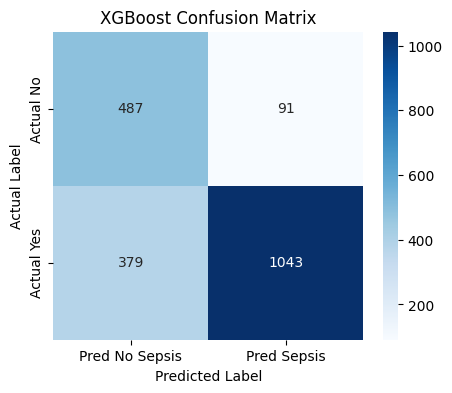


--- CatBoost Performance ---
ROC-AUC Score: 0.835 (Overall ability to distinguish classes)

Classification Report:
               precision    recall  f1-score   support

No Sepsis (0)       0.55      0.86      0.67       578
   Sepsis (1)       0.93      0.72      0.81      1422

     accuracy                           0.76      2000
    macro avg       0.74      0.79      0.74      2000
 weighted avg       0.82      0.76      0.77      2000



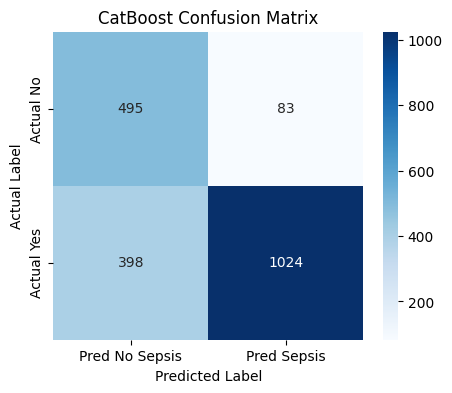

In [11]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Starting Step 5: Model Training...")

# 1. Dynamically calculate the XGBoost weight (Count of 0s / Count of 1s)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# --- Train XGBoost ---
print("\nTraining XGBoost...")
xgb_model = XGBClassifier(
    scale_pos_weight=ratio,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_xgb, y_train)

# --- Train CatBoost ---
print("Training CatBoost...")
cat_model = CatBoostClassifier(
    auto_class_weights='Balanced',
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=0 
)
# Note: We pass the specific cat_features_list we created earlier
cat_model.fit(X_train_cat, y_train, cat_features=cat_features_list)

print("\nStarting Step 6: Evaluation Metrics...")

# --- Evaluation Function ---
def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # We use ROC-AUC here because the classes are much more balanced (70/30)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    print(f"\n{'='*40}")
    print(f"--- {name} Performance ---")
    print(f"ROC-AUC Score: {roc_auc:.3f} (Overall ability to distinguish classes)")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Sepsis (0)', 'Sepsis (1)']))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Pred No Sepsis', 'Pred Sepsis'], 
                yticklabels=['Actual No', 'Actual Yes'])
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Run the evaluations!
evaluate_model(xgb_model, "XGBoost", X_test_xgb, y_test)
evaluate_model(cat_model, "CatBoost", X_test_cat, y_test)

In [12]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# Get the raw probabilities from the winning CatBoost model
y_prob_cat = cat_model.predict_proba(X_test_cat)[:, 1]

# Calculate precision and recall across all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_cat)

# Target: 85% Recall
target_recall = 0.85
idx = np.where(recall >= target_recall)[0][-1]
optimal_threshold = thresholds[idx]

print(f"To achieve {target_recall*100}% Recall, lower threshold to: {optimal_threshold:.4f}")
print(f"At this threshold, expected Precision will be: {precision[idx]:.4f}")

# Apply the new threshold
y_pred_optimal = (y_prob_cat >= optimal_threshold).astype(int)

print("\n--- CatBoost Performance at Optimal Threshold (85% Recall Targeted) ---")
print(classification_report(y_test, y_pred_optimal, target_names=['No Sepsis (0)', 'Sepsis (1)']))

To achieve 85.0% Recall, lower threshold to: 0.2484
At this threshold, expected Precision will be: 0.8275

--- CatBoost Performance at Optimal Threshold (85% Recall Targeted) ---
               precision    recall  f1-score   support

No Sepsis (0)       0.60      0.56      0.58       578
   Sepsis (1)       0.83      0.85      0.84      1422

     accuracy                           0.77      2000
    macro avg       0.72      0.71      0.71      2000
 weighted avg       0.76      0.77      0.77      2000



1. Generating Soft Voting Ensemble...
2. Generating Visual Outputs...


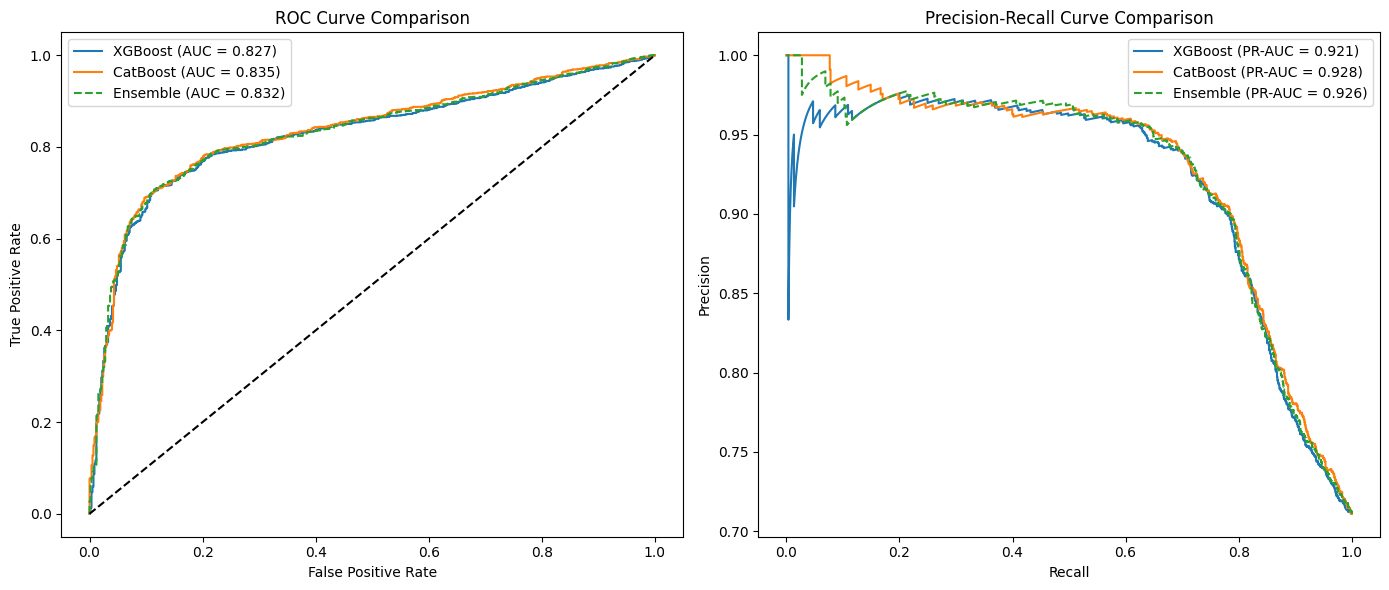

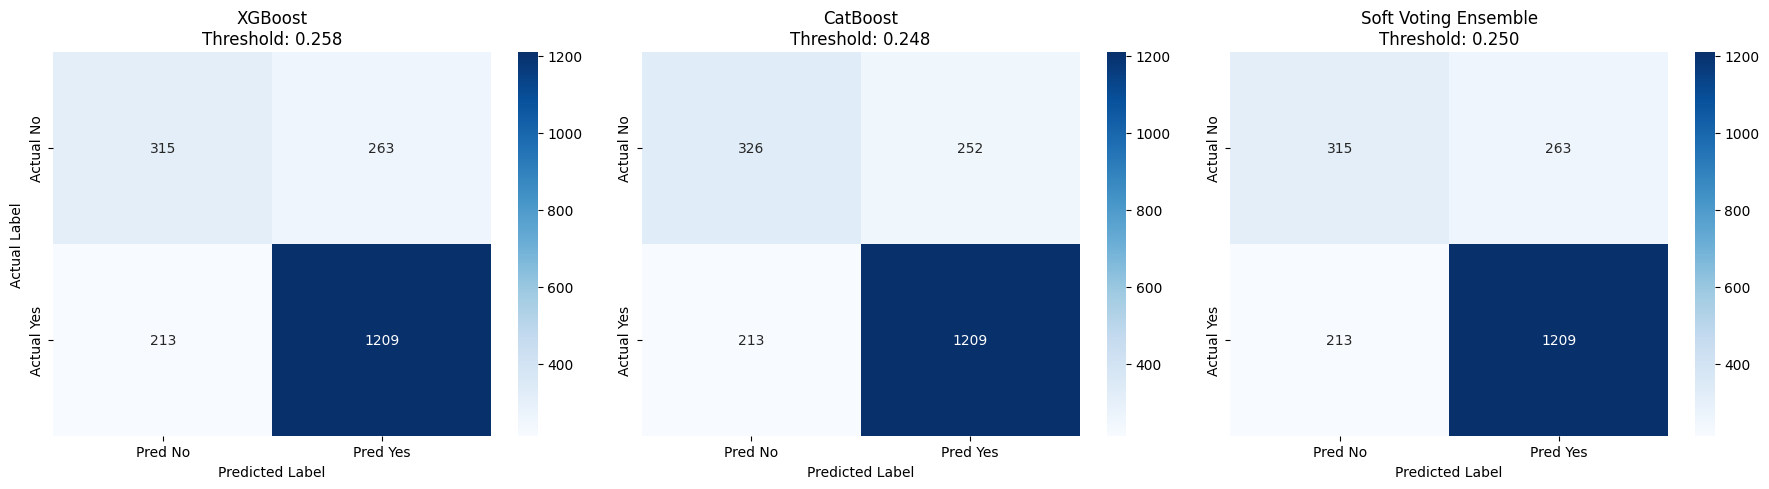

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, roc_auc_score

print("1. Generating Soft Voting Ensemble...")
# Soft Voting: Average the probabilities of both models
y_prob_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]
y_prob_cat = cat_model.predict_proba(X_test_cat)[:, 1]
y_prob_ens = (y_prob_xgb + y_prob_cat) / 2

# --- Threshold Tuning (Target: 85% Recall) ---
def get_optimal_preds(y_true, y_probs, target_recall=0.85):
    prec, rec, thresh = precision_recall_curve(y_true, y_probs)
    idx = np.where(rec >= target_recall)[0][-1]
    opt_thresh = thresh[idx]
    y_pred = (y_probs >= opt_thresh).astype(int)
    return y_pred, opt_thresh, auc(rec, prec)

y_pred_xgb, thresh_xgb, pr_auc_xgb = get_optimal_preds(y_test, y_prob_xgb)
y_pred_cat, thresh_cat, pr_auc_cat = get_optimal_preds(y_test, y_prob_cat)
y_pred_ens, thresh_ens, pr_auc_ens = get_optimal_preds(y_test, y_prob_ens)

print("2. Generating Visual Outputs...")

# ==========================================
# CHART 1 & 2: ROC and PR Curves Side-by-Side
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
fpr_x, tpr_x, _ = roc_curve(y_test, y_prob_xgb)
fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_cat)
fpr_e, tpr_e, _ = roc_curve(y_test, y_prob_ens)

axes[0].plot(fpr_x, tpr_x, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})')
axes[0].plot(fpr_c, tpr_c, label=f'CatBoost (AUC = {roc_auc_score(y_test, y_prob_cat):.3f})')
axes[0].plot(fpr_e, tpr_e, label=f'Ensemble (AUC = {roc_auc_score(y_test, y_prob_ens):.3f})', linestyle='--')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('ROC Curve Comparison')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Precision-Recall Curve
prec_x, rec_x, _ = precision_recall_curve(y_test, y_prob_xgb)
prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob_cat)
prec_e, rec_e, _ = precision_recall_curve(y_test, y_prob_ens)

axes[1].plot(rec_x, prec_x, label=f'XGBoost (PR-AUC = {pr_auc_xgb:.3f})')
axes[1].plot(rec_c, prec_c, label=f'CatBoost (PR-AUC = {pr_auc_cat:.3f})')
axes[1].plot(rec_e, prec_e, label=f'Ensemble (PR-AUC = {pr_auc_ens:.3f})', linestyle='--')
axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

# ==========================================
# CHART 3: Confusion Matrices Comparison
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_info = [
    ("XGBoost", y_pred_xgb, thresh_xgb),
    ("CatBoost", y_pred_cat, thresh_cat),
    ("Soft Voting Ensemble", y_pred_ens, thresh_ens)
]

for i, (name, y_pred, thresh) in enumerate(models_info):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Pred No', 'Pred Yes'], 
                yticklabels=['Actual No', 'Actual Yes'])
    axes[i].set_title(f'{name}\nThreshold: {thresh:.3f}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('Actual Label' if i == 0 else '')

plt.tight_layout()
plt.show()